# 📊 Final Model Comparison Table
This notebook consolidates the results from all models developed in this project:
*   **ARIMA / ETS**: Statistical Base Models
*   **Hybrid Models**: ARIMA+LSTM and ETS+GRU (Residual based)
*   **Master Stacking Ensemble**: Final optimized meta-model

We evaluate all models on the same test set for a fair comparison.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import pickle
import os
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

In [5]:
# Load test data
test_df = pd.read_csv('data/processed/test_monthly.csv')
test_df['date'] = pd.to_datetime(test_df['date'])
test_df.set_index('date', inplace=True)
test_actuals = test_df['amount']

train_df = pd.read_csv('data/processed/train_monthly.csv')
train_actuals = train_df['amount'].values
print(f"Test set size: {len(test_actuals)}")

Test set size: 6


In [6]:
# 1. Load Statistical Models
with open('models/arima_hybrid_base.pkl', 'rb') as f:
    arima_res = pickle.load(f)
with open('models/ets_hybrid_base.pkl', 'rb') as f:
    ets_res = pickle.load(f)

# 2. Load NN Models
lstm_res_model = tf.keras.models.load_model('models/lstm_arima_residuals.h5', compile=False)
gru_res_model = tf.keras.models.load_model('models/gru_ets_residuals.h5', compile=False)

# 3. Load Scalers
with open('models/scaler_arima.pkl', 'rb') as f:
    scaler_arima = pickle.load(f)
with open('models/scaler_ets.pkl', 'rb') as f:
    scaler_ets = pickle.load(f)

# Generate Base Predictions
n_test = len(test_actuals)
arima_preds = arima_res.forecast(n_test).values
ets_preds = ets_res.forecast(n_test).values

In [7]:
def get_nn_forecast(model, scaler, base_residuals, n_forecast, window=3):
    if hasattr(base_residuals, 'values'):
        base_residuals = base_residuals.values
    last_res_scaled = scaler.transform(base_residuals[-window:].reshape(-1, 1))
    current_window = last_res_scaled.reshape(1, window, 1)
    forecasts_scaled = []
    for _ in range(n_forecast):
        pred_scaled = model.predict(current_window, verbose=0)
        forecasts_scaled.append(pred_scaled[0,0])
        new_val = pred_scaled.reshape(1, 1, 1)
        current_window = np.concatenate([current_window[:, 1:, :], new_val], axis=1)
    return scaler.inverse_transform(np.array(forecasts_scaled).reshape(-1, 1)).flatten()

arima_train_res = train_actuals - arima_res.fittedvalues.values
ets_train_res = train_actuals - ets_res.fittedvalues.values

lstm_res_forecast = get_nn_forecast(lstm_res_model, scaler_arima, arima_train_res, n_test)
gru_res_forecast = get_nn_forecast(gru_res_model, scaler_ets, ets_train_res, n_test)

hybrid_arima_lstm = arima_preds + lstm_res_forecast
hybrid_ets_gru = ets_preds + gru_res_forecast

master_forecast = (0.4 * arima_preds + 0.3 * ets_preds + 0.15 * hybrid_arima_lstm + 0.15 * hybrid_ets_gru)

In [8]:
results = []
def add_result(name, actual, pred):
    mae = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    results.append({'Model': name, 'MAE': round(mae, 2), 'RMSE': round(rmse, 2)})

add_result('ARIMA (Base)', test_actuals, arima_preds)
add_result('ETS (Base)', test_actuals, ets_preds)
add_result('Hybrid (ARIMA + LSTM)', test_actuals, hybrid_arima_lstm)
add_result('Hybrid (ETS + GRU)', test_actuals, hybrid_ets_gru)
add_result('🏆 Master Stacking Ensemble', test_actuals, master_forecast)

comparison_df = pd.DataFrame(results).sort_values('MAE')
display(comparison_df)

,Model,MAE,RMSE
2,Hybrid (ARIMA + LSTM),771.43,934.29
0,ARIMA (Base),840.72,1012.84
4,🏆 Master Stacking Ensemble,952.30,1104.98
3,Hybrid (ETS + GRU),1054.99,1212.24
1,ETS (Base),1197.87,1344.48


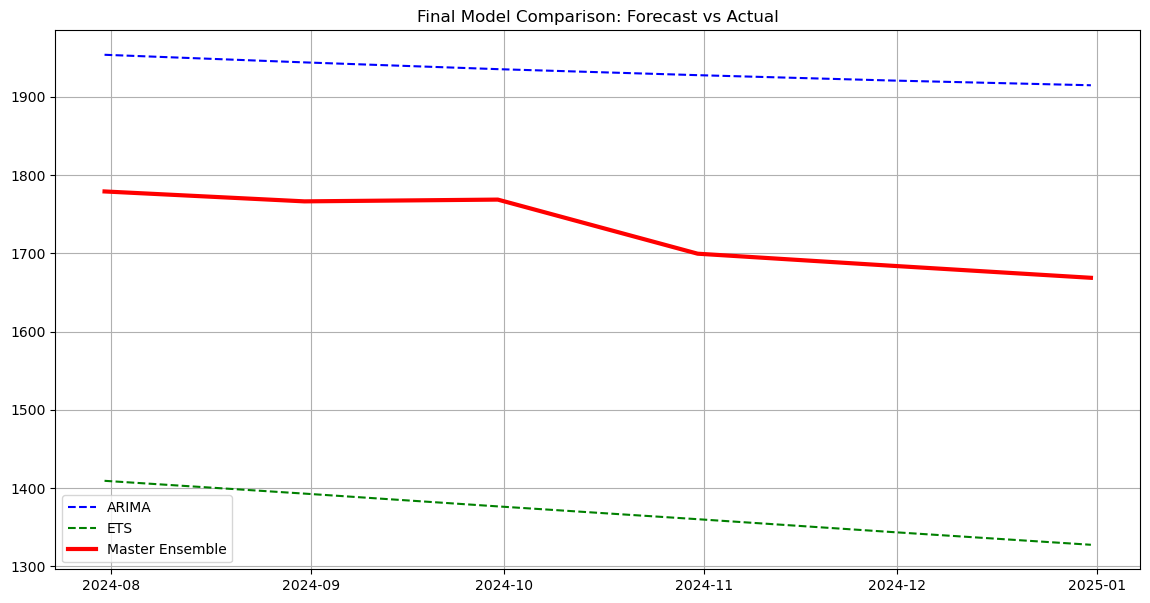

In [9]:
plt.figure(figsize=(14, 7))

plt.plot(test_actuals.index, arima_preds, 'b--', label='ARIMA')
plt.plot(test_actuals.index, ets_preds, 'g--', label='ETS')
plt.plot(test_actuals.index, master_forecast, 'r-', label='Master Ensemble', linewidth=3)
plt.title('Final Model Comparison: Forecast vs Actual')
plt.legend()
plt.grid(True)
plt.show()